# BreathWise Dataset: Exploratory Data Analysis (EDA)
This notebook provides a deep dive into the statistical properties and visual characteristics of our filtered X-Ray dataset. Understanding the data distribution is critical for evaluating potential biases and interpreting our deep learning model's performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

# Set beautiful plot styles for presentations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

DATA_DIR = '../resized_dataset/resized_images/'
CSV_PATH = '../resized_dataset/resized_labels.csv'

DISEASES = ['Pneumonia', 'Effusion', 'Cardiomegaly', 'Pneumothorax', 'No Finding']

## 1. Data Loading and High-Level Overview

In [2]:
df = pd.read_csv(CSV_PATH)

print("Dataset Shape:", df.shape)
print(f"Total X-Ray Images: {len(df):,}")
display(df.head())

Dataset Shape: (23274, 6)
Total X-Ray Images: 23,274


,Path,No Finding,Pneumonia,Pneumothorax,Effusion,Cardiomegaly
0,images/00000001_000.png,0,0,0,0,1
1,images/00000001_001.png,0,0,0,0,1
2,images/00000001_002.png,0,0,0,1,1
3,images/00000002_000.png,1,0,0,0,0
4,images/00000005_005.png,1,0,0,0,0


## 2. Disease Class Distribution
Let's visualize the frequency of each condition in our dataset. Medical datasets are notoriously imbalanced, which our model must account for via weighted loss functions during training.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14408\3370986086.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette="viridis")


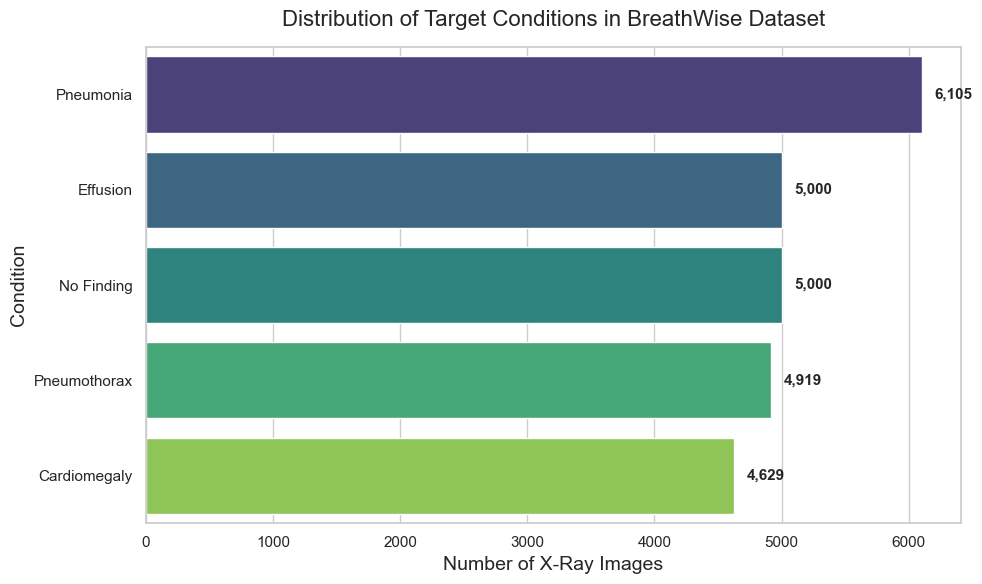

In [3]:
counts = df[DISEASES].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts.values, y=counts.index, palette="viridis")

plt.title('Distribution of Target Conditions in BreathWise Dataset', fontsize=16, pad=15)
plt.xlabel('Number of X-Ray Images', fontsize=14)
plt.ylabel('Condition', fontsize=14)

# Add count labels to the bars
for i, v in enumerate(counts.values):
    ax.text(v + 100, i, f"{v:,}", va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Co-Occurrence Analysis (Comorbidities)
Patients often have multiple pulmonary conditions simultaneously (e.g., Pneumonia leading to Pleural Effusion). This heatmap mathematically shows the correlation and co-occurrence between different diseases.

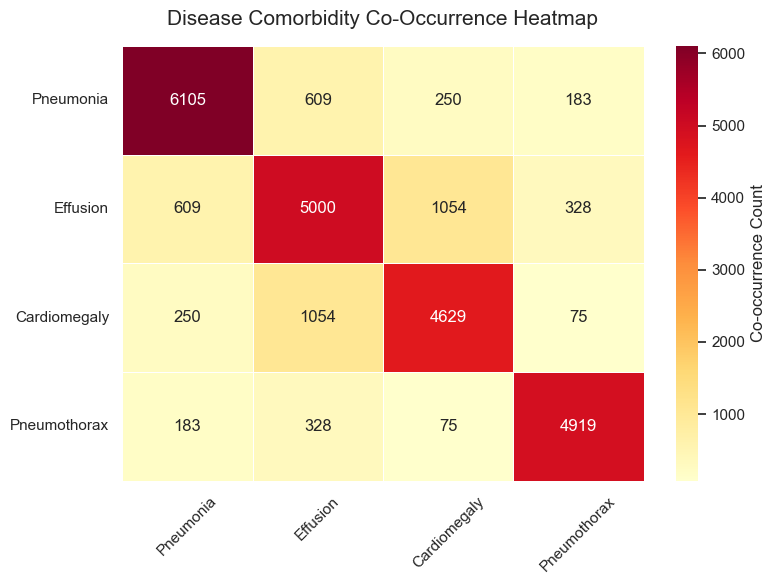

In [4]:
# Drop 'No Finding' for co-occurrence since it is mutually exclusive with diseases
disease_df = df[DISEASES[:-1]]

# Calculate co-occurrence matrix
co_matrix = disease_df.T.dot(disease_df)

plt.figure(figsize=(8, 6))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="YlOrRd", 
            linewidths=.5, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Disease Comorbidity Co-Occurrence Heatmap', fontsize=15, pad=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Visualizing X-Rays by Class
Let's pull a random sample of images for each specific condition to observe the radiological patterns our DenseNet-121 model will learn. We will render them using the standard medical 'bone' colormap.

Not enough samples for Pneumonia
Not enough samples for Effusion
Not enough samples for Cardiomegaly
Not enough samples for Pneumothorax
Not enough samples for No Finding


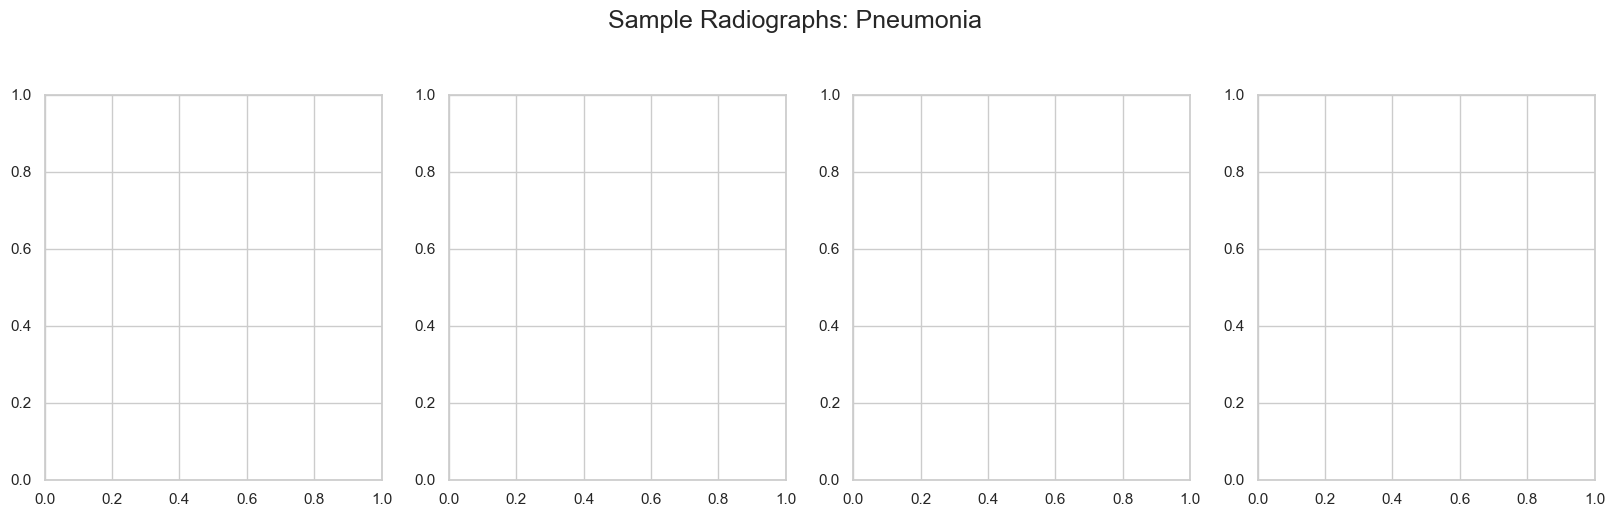

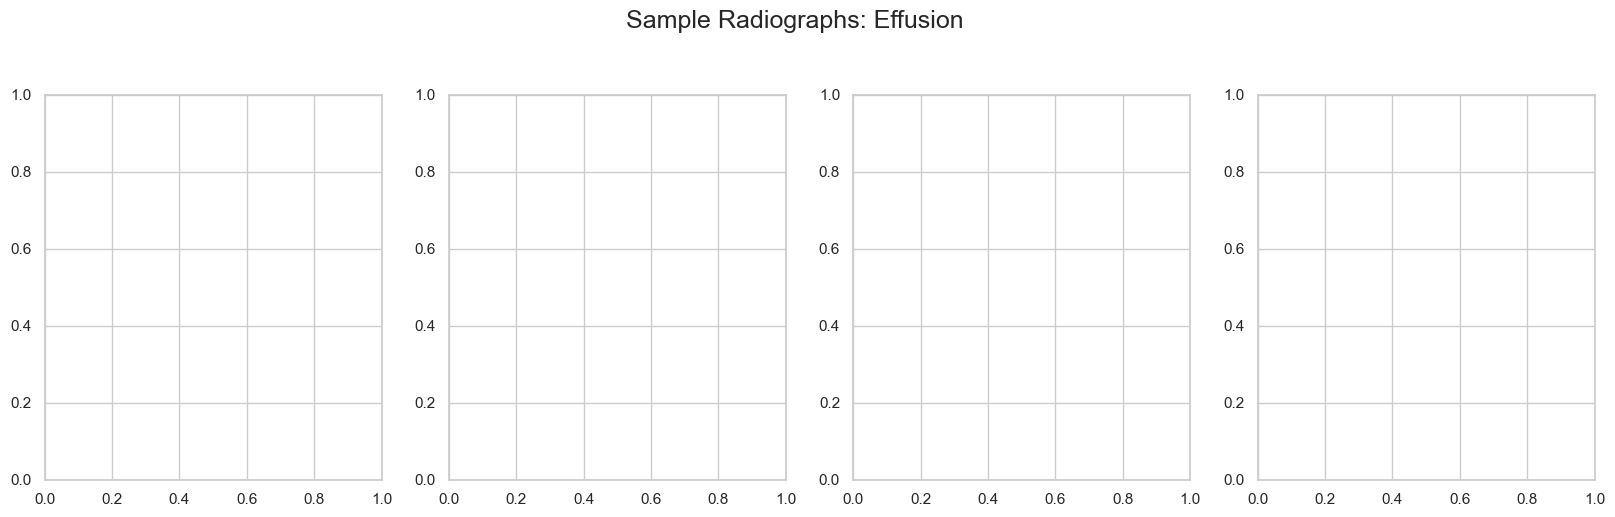

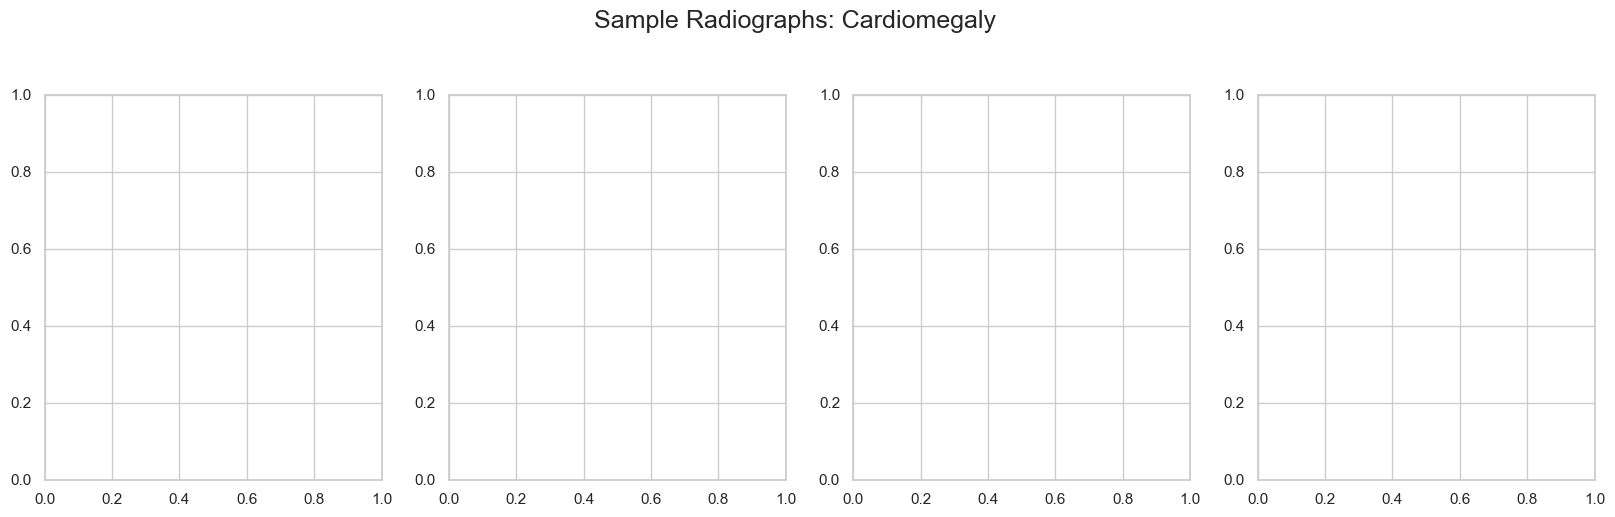

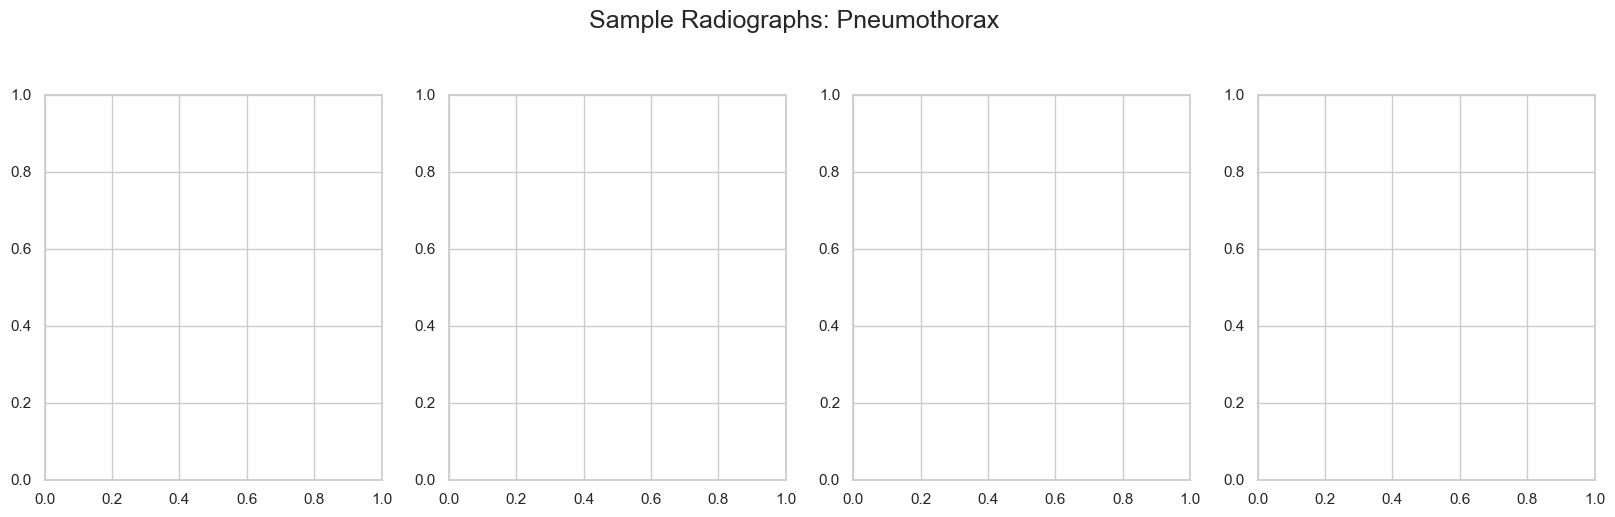

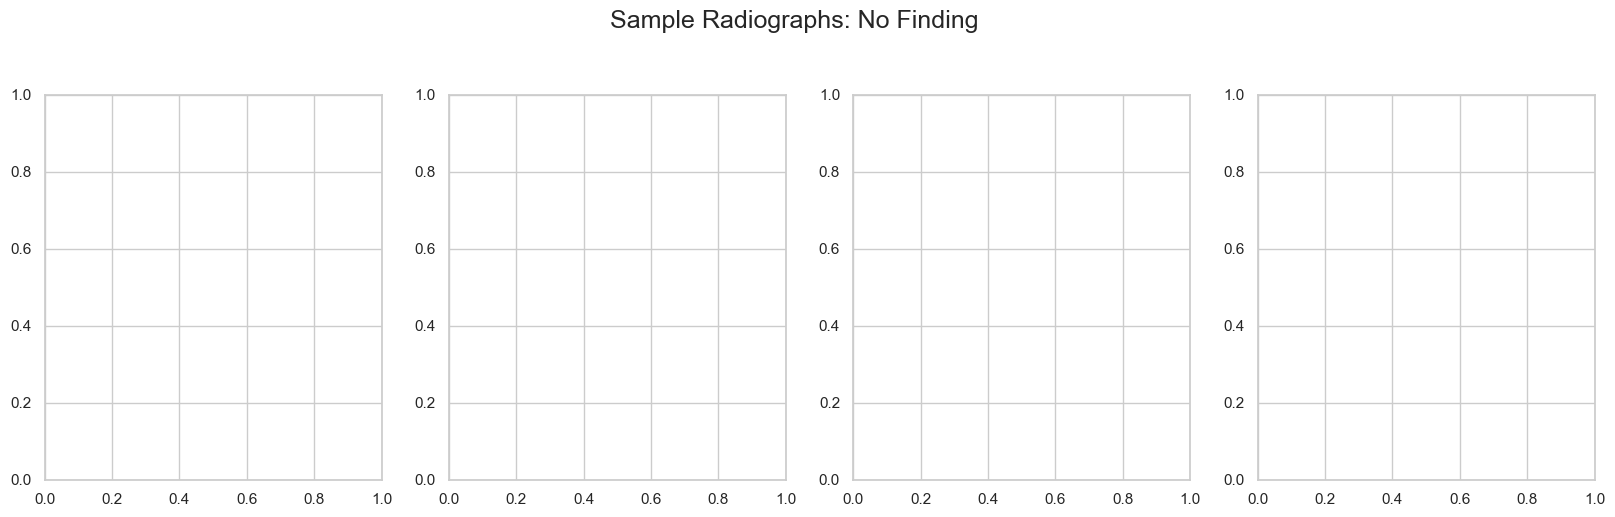

In [5]:
def plot_disease_samples(disease_name, num_samples=4):
    # Get images that ONLY have this specific disease (for clear visualization)
    if disease_name == 'No Finding':
        sample_df = df[df['No Finding'] == 1].sample(num_samples, random_state=42)
    else:
        # Get rows where this disease is 1, and everything else is 0
        other_diseases = [d for d in DISEASES if d != disease_name]
        mask = (df[disease_name] == 1) & (df[other_diseases].sum(axis=1) == 0)
        
        # In case we don't have enough pure samples, just take any with the disease
        if len(df[mask]) >= num_samples:
            sample_df = df[mask].sample(num_samples, random_state=42)
        else:
            sample_df = df[df[disease_name] == 1].sample(num_samples, random_state=42)
        
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
    fig.suptitle(f"Sample Radiographs: {disease_name}", fontsize=18, y=1.05)
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        img_path = os.path.join(DATA_DIR, row['Image_Index'])
        if os.path.exists(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            axes[i].imshow(img, cmap='bone') # 'bone' colormap is standard for X-Rays
            axes[i].set_title(f"ID: {row['Image_Index']}", fontsize=10)
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, 'Image Missing', ha='center')
            axes[i].axis('off')
            
    plt.show()

# Plot samples for each condition
for condition in DISEASES:
    try:
        plot_disease_samples(condition)
    except Exception as e:
        print(f"Not enough samples for {condition}")